<a href="https://colab.research.google.com/github/halimAhtasham/DeepLearning/blob/main/04_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction

## Phase 4: Model Training

### Objective

Train and compare several supervised machine learning classification
models for predicting heart disease.

Models:
1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest

In [31]:
import pandas as pd
import numpy as np
import joblib


from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [29]:
import matplotlib.pyplot as plt

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
PROJECT_PATH = "/content/drive/MyDrive/Machine Learning/Projects/Heart Disease Prediction"

DATASET_PATH = PROJECT_PATH+"/Dataset"
MODEL_PATH = PROJECT_PATH+"/Models"
IMAGE_PATH = PROJECT_PATH+"/Images"

In [11]:
df = pd.read_csv(DATASET_PATH + "/heart.csv")

In [12]:
df_clean = df.drop_duplicates().copy()
print("Original: ", df.shape)
print("Cleaned : ",df_clean.shape)

Original:  (1025, 14)
Cleaned :  (302, 14)


In [13]:
X = df_clean.drop('target', axis=1)
y = df_clean['target']

In [14]:
print(X.shape)
print(y.shape)

(302, 13)
(302,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify = y
)

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(241, 13)
(61, 13)
(241,)
(61,)


In [17]:
Scaler = StandardScaler()

X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)

In [18]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

## 2. Logistic Regression

Logistic Regression will be used as our baseline classification model.

It estimates the probability that an observation belongs to a particular
class and can be used for binary classification.

In [20]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [21]:
logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [22]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

In [23]:
print(y_pred_logistic)

[0 1 0 1 1 0 1 0 1 1 1 0 1 1 0 1 1 0 1 1 0 0 1 0 1 0 0 0 0 1 0 1 1 1 0 1 0
 1 1 1 0 1 1 1 0 0 1 0 1 1 0 1 1 0 1 1 0 1 0 0 1]


In [24]:
comparision = pd.DataFrame(
    {
        "Actual": y_test,
        "Predicted": y_pred_logistic
    }
)
comparision.head(15)

,Actual,Predicted
25,0,0
65,0,1
437,0,0
58,0,1
42,0,1
177,0,0
473,1,1
2,0,0
434,1,1
142,0,1


In [25]:
accuracy = accuracy_score(y_test, y_pred_logistic)
print("Logistic Regression: ", accuracy)

Logistic Regression:  0.8032786885245902


In [26]:
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [27]:
cm = confusion_matrix(y_test, y_pred_logistic)
print(cm)

[[21  7]
 [ 5 28]]


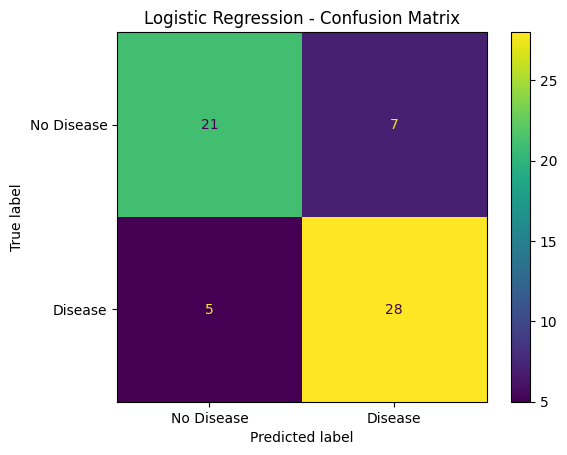

In [32]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [33]:
joblib.dump(
    logistic_model,
    MODEL_PATH + "/logistic_regression.pkl"
)

['/content/drive/MyDrive/Machine Learning/Projects/Heart Disease Prediction/Models/logistic_regression.pkl']